The aim of this project is to predict whether an online shopper will make a purchase based on their e-commerce shopping behavior. The target variable is Revenue, which represents whether the customer completed a purchase during their shopping session

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


### Dataset Loading

In [39]:
df=pd.read_csv("online_shoppers_intention.csv");
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [44]:
print("Shape:", df.shape)

print("Columns:", df.columns)

print("Data Types:", df.dtypes)

print("Missing Values:", df.isnull().sum())

print("Duplicate Rows:", df.duplicated().sum())

print("Statistical summary:" ,df.describe())
df.info()

Shape: (12330, 18)
Columns: Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='str')
Data Types: Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue            

In [41]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12330, 17)
y shape: (12330,)


<h4>Distrubution of Numerical Features</h4>

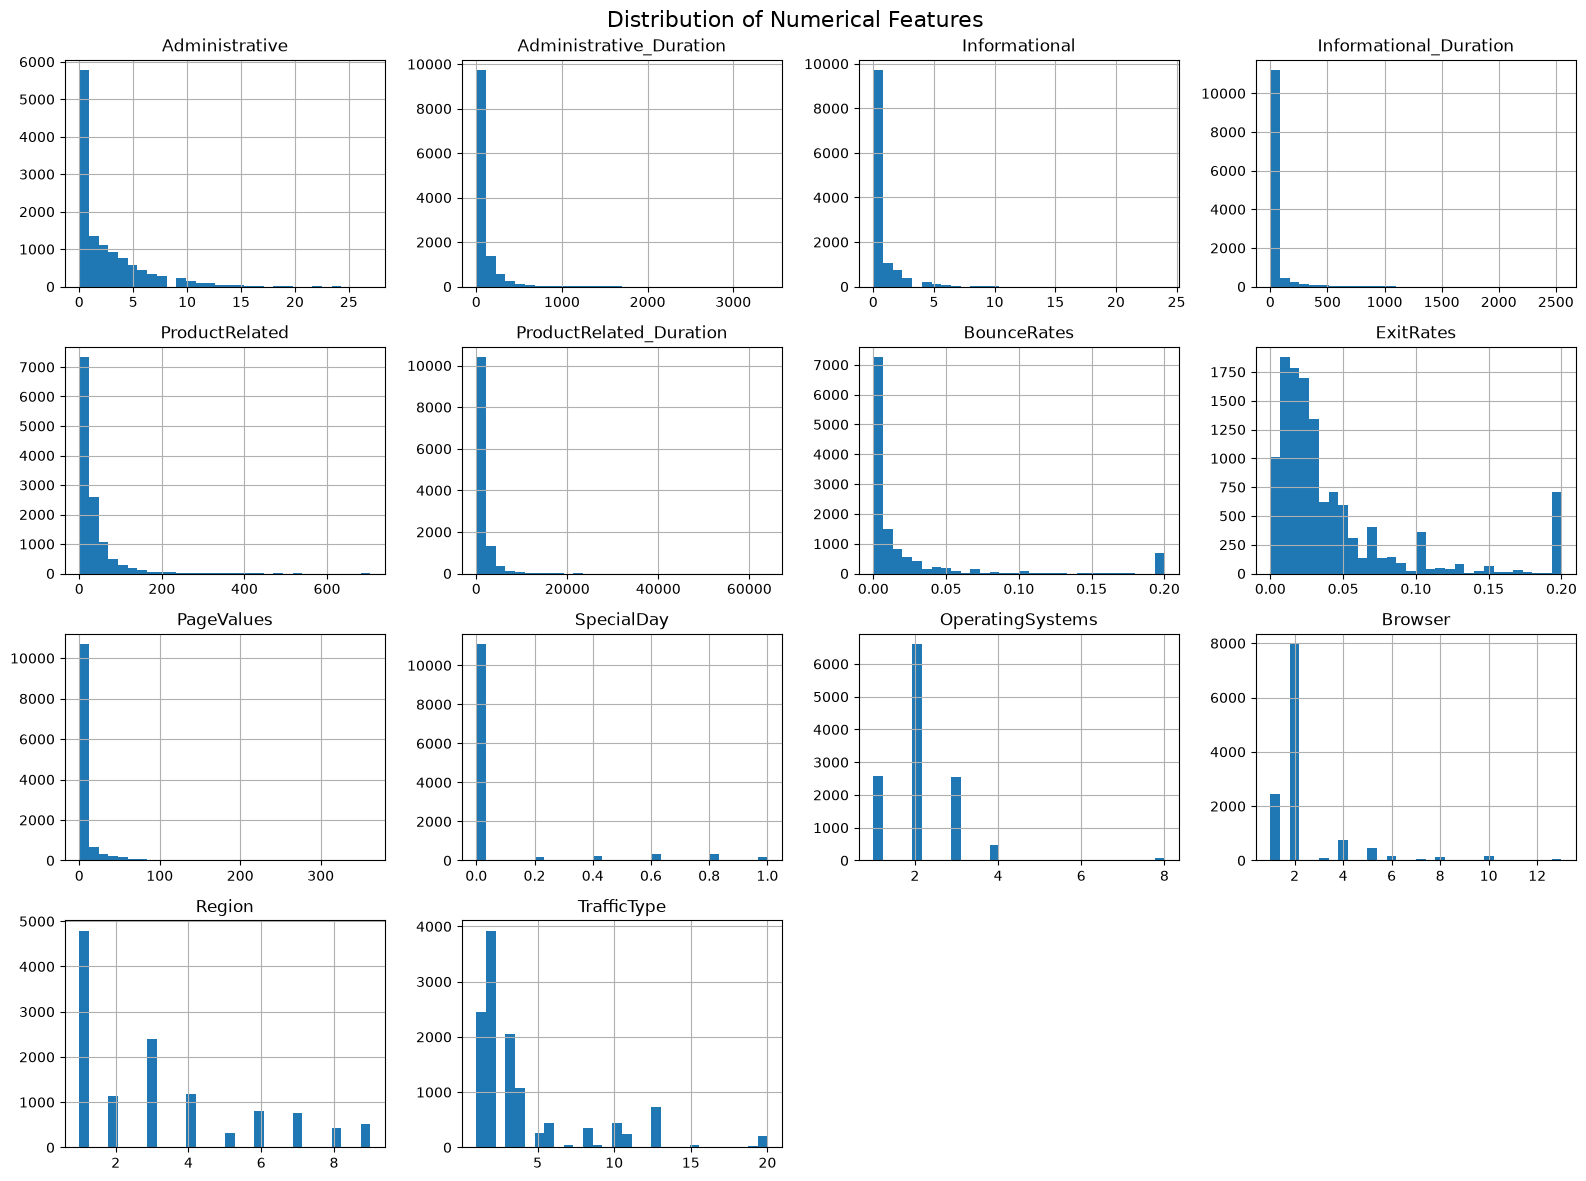

In [42]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

Most values are low, while a few sessions have very high values.
This shows that the data is right-skewed, and the features have different scales.

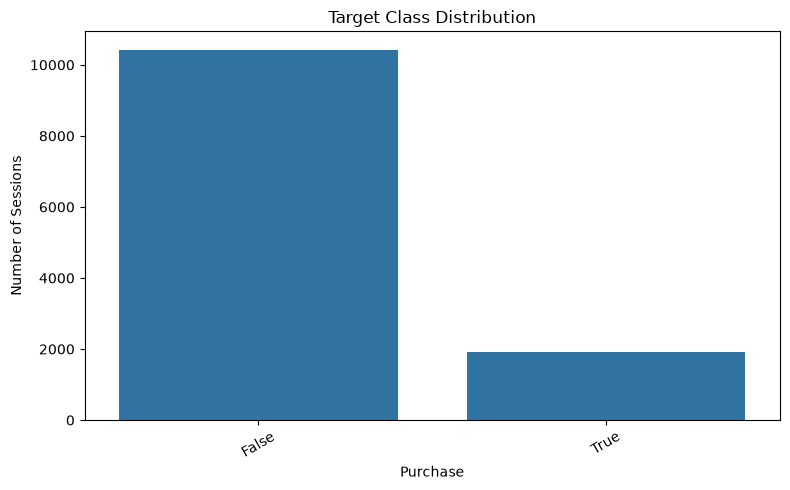

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Revenue"
)

plt.xlabel("Purchase")
plt.ylabel("Number of Sessions")
plt.title("Target Class Distribution")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Most sessions do not result in a purchase, while only a smaller proportion lead to a purchase, indicating an imbalance between the target classes.

<h4>Correlation Heatmap</h4>

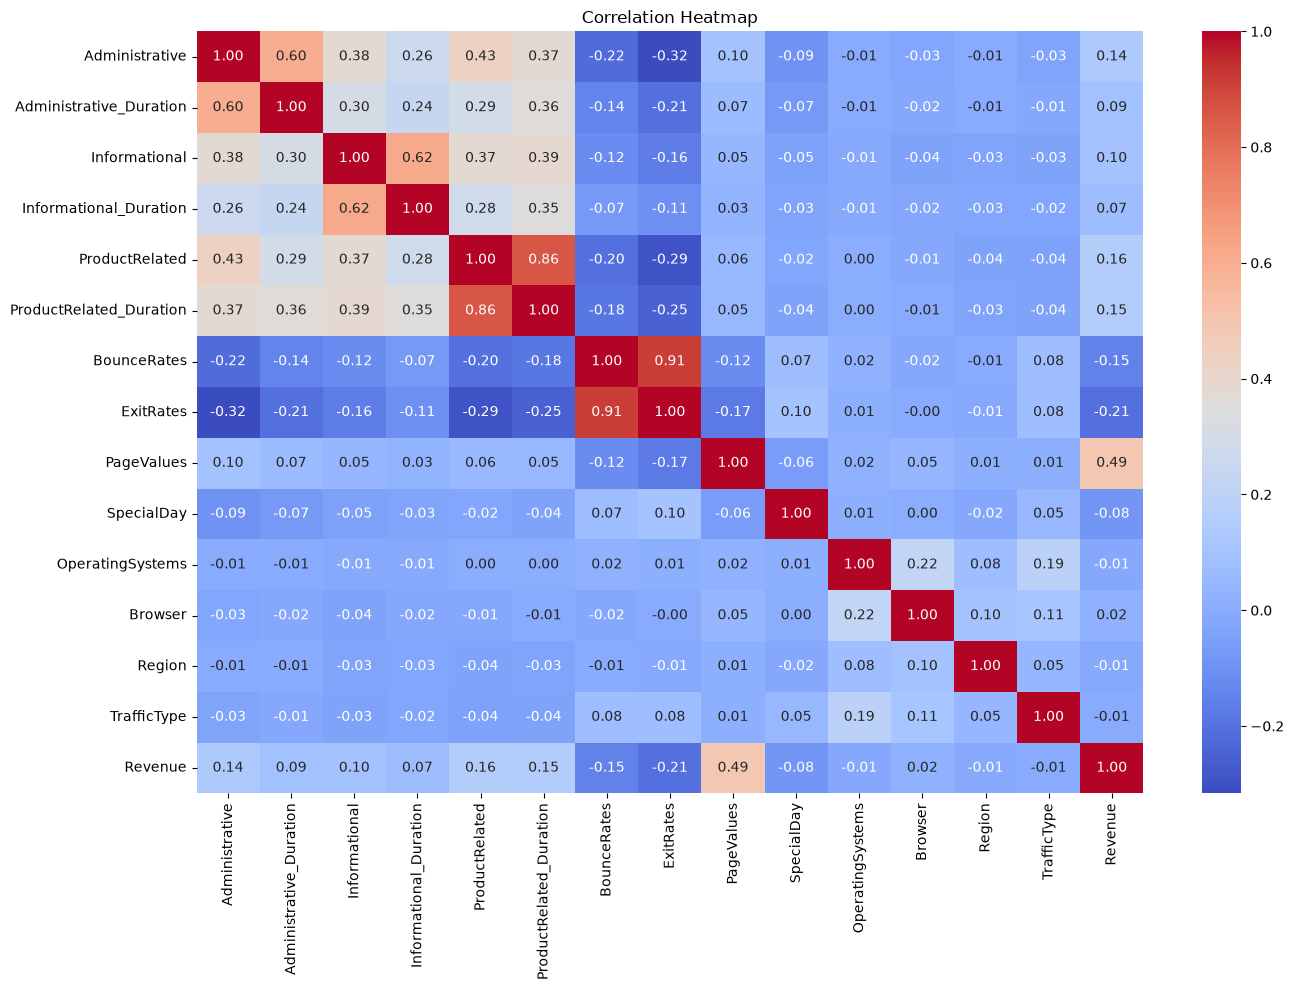

In [8]:
correlation = df.copy()
correlation["Revenue"] = correlation["Revenue"].astype(int)

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


The heatmap shows how the numerical features are related to each other and to Revenue. Some browsing features have stronger relationships, while others have weak relationships.

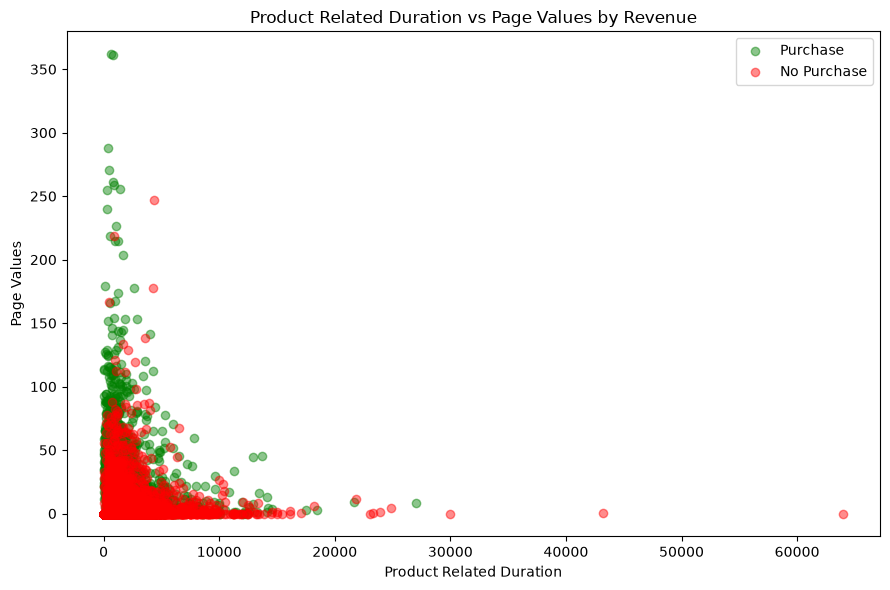

In [9]:
plt.figure(figsize=(9, 6))

for value, color, label in [(True, "green", "Purchase"), (False, "red", "No Purchase")]:
    data = df[df["Revenue"] == value]
    plt.scatter(
        data["ProductRelated_Duration"],
        data["PageValues"],
        color=color,
        alpha=0.45,
        label=label
    )

plt.xlabel("Product Related Duration")
plt.ylabel("Page Values")
plt.title("Product Related Duration vs Page Values by Revenue")
plt.legend()
plt.tight_layout()
plt.show()

High Page Values occur at low to moderate durations. Sessions with high Page Values are mostly purchases, so Page Values separates the two classes better than duration does.

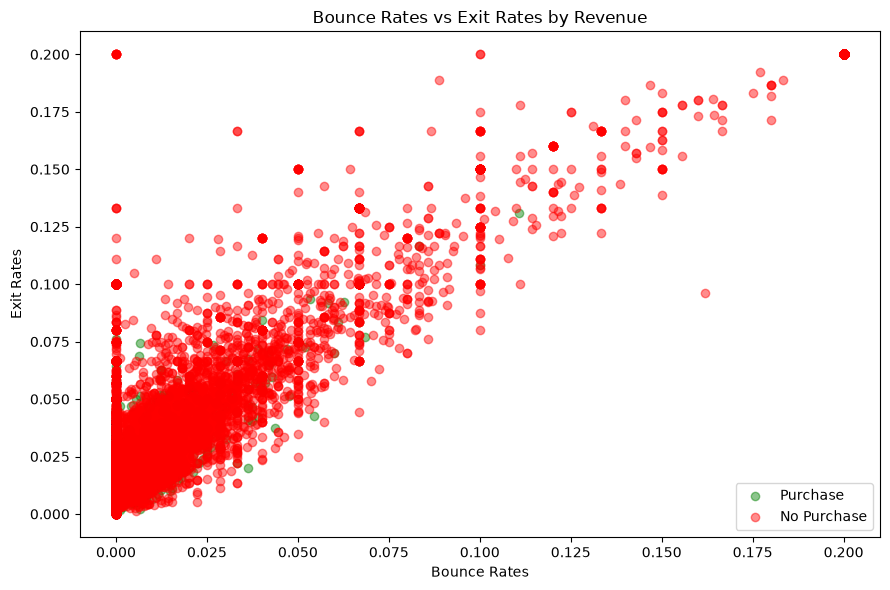

In [10]:
plt.figure(figsize=(9, 6))

for value, color, label in [
    (True, "green", "Purchase"),
    (False, "red", "No Purchase")
]:
    data = df[df["Revenue"] == value]

    plt.scatter(
        data["BounceRates"],
        data["ExitRates"],
        color=color,
        alpha=0.45,
        label=label
    )

plt.xlabel("Bounce Rates")
plt.ylabel("Exit Rates")
plt.title("Bounce Rates vs Exit Rates by Revenue")
plt.legend()

plt.tight_layout()
plt.show()

The plot shows that Bounce Rates and Exit Rates increase together. Both Purchase and No Purchase sessions appear in the same areas, so the two groups do not have a clear separation.

## Data Preprocessing and Feature Engineering

<h4>Missing Value Handling</h4>

In [11]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 125


In [13]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (12205, 18)


In [24]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Total_Duration', 'Total_Pages'],
      dtype='str')

Target:
Revenue


In [25]:
numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(
    include=["object", "str", "bool"]).columns

for column in numeric_columns:
    if df[column].isnull().any():
        df[column] = df[column].fillna(df[column].median())

for column in categorical_columns:
    if df[column].isnull().any():
        df[column] = df[column].fillna(df[column].mode()[0])

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
Total_Duration             0
Total_Pages                0
dtype: int64


<h4>Handling Outliers </h4>

In [26]:
numeric_features = df.select_dtypes(include=np.number).columns

for column in numeric_features:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower, upper)
print(X.shape)

(12205, 19)


<h4>Feature Engineering</h4>

In [27]:
df["Total_Duration"] = (
    df["Administrative_Duration"]
    + df["Informational_Duration"]
    + df["ProductRelated_Duration"]
)

df["Total_Pages"] = (
    df["Administrative"]
    + df["Informational"]
    + df["ProductRelated"]
)

print(df[["Total_Duration", "Total_Pages"]].head())
df.head()

   Total_Duration  Total_Pages
0        0.000000            1
1       64.000000            2
2        0.000000            1
3        2.666667            2
4      627.500000           10


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Total_Duration,Total_Pages
0,0,0.0,0,0.0,1,0.000000,0.041667,0.099977,0.0,0.0,Feb,1.0,2,1.0,1,Returning_Visitor,False,False,0.000000,1
1,0,0.0,0,0.0,2,64.000000,0.000000,0.099977,0.0,0.0,Feb,2.0,2,1.0,2,Returning_Visitor,False,False,64.000000,2
2,0,0.0,0,0.0,1,0.000000,0.041667,0.099977,0.0,0.0,Feb,4.0,2,8.5,3,Returning_Visitor,False,False,0.000000,1
3,0,0.0,0,0.0,2,2.666667,0.041667,0.099977,0.0,0.0,Feb,3.0,2,2.0,4,Returning_Visitor,False,False,2.666667,2
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3.0,2,1.0,4,Returning_Visitor,True,False,627.500000,10


In [28]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

categorical_features = list(
    X.select_dtypes(include=["object", "str", "bool"]).columns
) + ["OperatingSystems", "Browser", "Region", "TrafficType"]

X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

print("Shape after encoding:", X.shape)
X.head()

Shape after encoding: (12205, 42)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Region_6.0,Region_7.0,Region_8.0,Region_8.5,TrafficType_2,TrafficType_3,TrafficType_4,TrafficType_5,TrafficType_6,TrafficType_7
0,0,0.0,0,0.0,1,0.000000,0.041667,0.099977,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.099977,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False
2,0,0.0,0,0.0,1,0.000000,0.041667,0.099977,0.0,0.0,...,False,False,False,True,False,True,False,False,False,False
3,0,0.0,0,0.0,2,2.666667,0.041667,0.099977,0.0,0.0,...,False,False,False,False,False,False,True,False,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,...,False,False,False,False,False,False,True,False,False,False


In [29]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Total_Duration,Total_Pages
0,0,0.0,0,0.0,1,0.000000,0.041667,0.099977,0.0,0.0,Feb,1.0,2,1.0,1,Returning_Visitor,False,False,0.000000,1
1,0,0.0,0,0.0,2,64.000000,0.000000,0.099977,0.0,0.0,Feb,2.0,2,1.0,2,Returning_Visitor,False,False,64.000000,2
2,0,0.0,0,0.0,1,0.000000,0.041667,0.099977,0.0,0.0,Feb,4.0,2,8.5,3,Returning_Visitor,False,False,0.000000,1
3,0,0.0,0,0.0,2,2.666667,0.041667,0.099977,0.0,0.0,Feb,3.0,2,2.0,4,Returning_Visitor,False,False,2.666667,2
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3.0,2,1.0,4,Returning_Visitor,True,False,627.500000,10


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (9764, 42)
Testing data: (2441, 42)


In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

StandardScaler was used to bring the numerical features to a similar scale. This is important because some features have larger values than others, which can affect distance-based and scale-sensitive models. The scaler was fitted only on the training data and then used to transform the test data to avoid data leakage.

<h2>Classification Algorithm Implementation</h2>

In [32]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        class_weight="balanced",
        random_state=42
    ),
    "Support Vector Machine": SVC(
        kernel="rbf",
        class_weight="balanced",
        random_state=42
    )
}

print("Number of algorithms:", len(models))


Number of algorithms: 5


In [33]:
results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)
    predictions[name] = pred

    accuracy = accuracy_score(y_test, pred)
    f1_weighted = f1_score(y_test, pred, average="weighted")
    f1_purchase = f1_score(y_test, pred)

    results.append([name, accuracy, f1_weighted, f1_purchase])

comparison = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Weighted F1", "Purchase F1"]
)

comparison = comparison.sort_values("Weighted F1", ascending=False).round(4).reset_index(drop=True)

display(comparison)

,Model,Accuracy,Weighted F1,Purchase F1
0,K-Nearest Neighbors,0.8222,0.7821,0.1423
1,Gaussian Naive Bayes,0.6796,0.7205,0.3744
2,Support Vector Machine,0.6731,0.7168,0.4045
3,Logistic Regression,0.6448,0.6933,0.4033
4,Decision Tree,0.6022,0.6561,0.3748


In [35]:
for name, pred in predictions.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(
        y_test,
        pred,
        target_names=["No Purchase", "Purchase"],
        zero_division=0
    ))


Logistic Regression
              precision    recall  f1-score   support

 No Purchase       0.94      0.62      0.75      2059
    Purchase       0.27      0.77      0.40       382

    accuracy                           0.64      2441
   macro avg       0.60      0.69      0.58      2441
weighted avg       0.83      0.64      0.69      2441

K-Nearest Neighbors
              precision    recall  f1-score   support

 No Purchase       0.85      0.96      0.90      2059
    Purchase       0.29      0.09      0.14       382

    accuracy                           0.82      2441
   macro avg       0.57      0.53      0.52      2441
weighted avg       0.76      0.82      0.78      2441

Gaussian Naive Bayes
              precision    recall  f1-score   support

 No Purchase       0.91      0.69      0.78      2059
    Purchase       0.27      0.61      0.37       382

    accuracy                           0.68      2441
   macro avg       0.59      0.65      0.58      2441
weighted avg 

<h2>Confusion Matrices</h2>

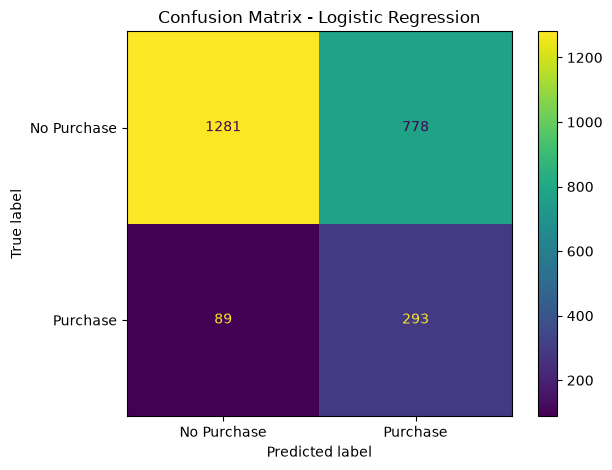

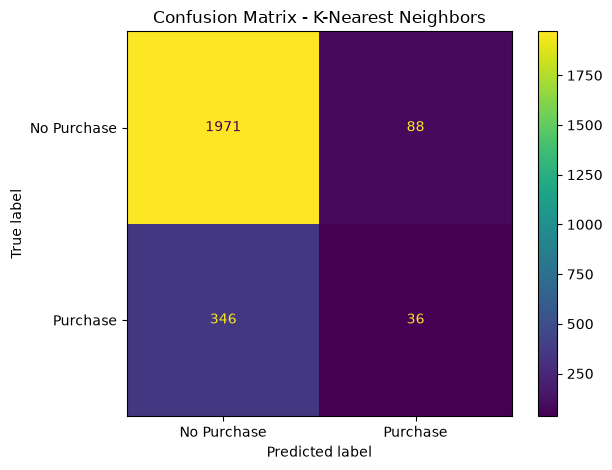

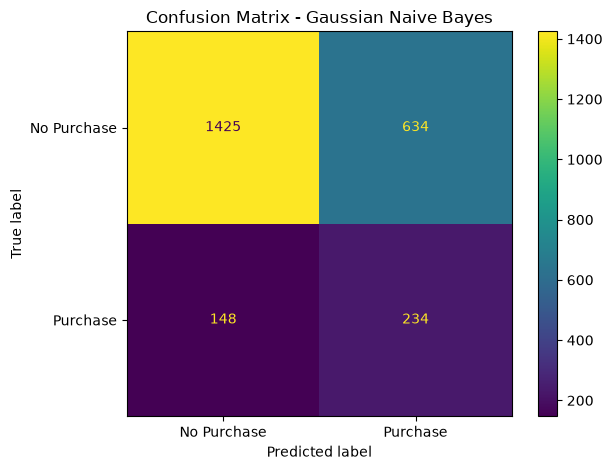

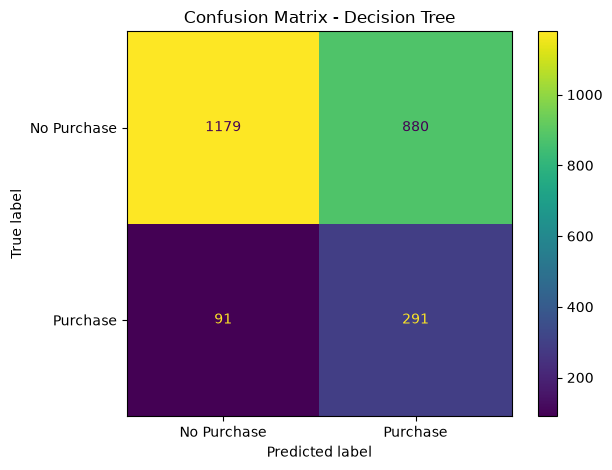

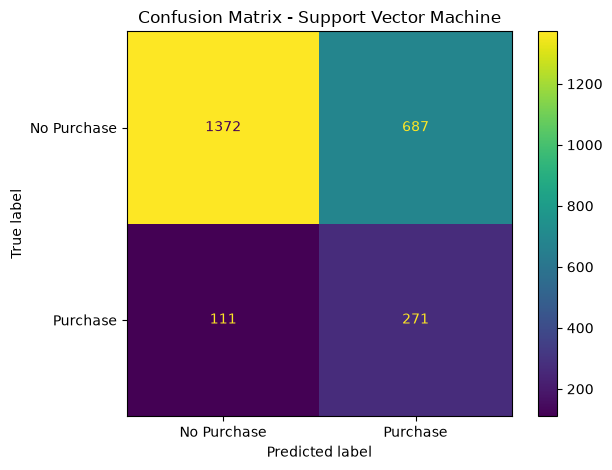

In [36]:
for name, pred in predictions.items():
    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Purchase", "Purchase"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()
